<a href="https://colab.research.google.com/github/Vanshu2374/data-science-45-days/blob/main/grass3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data Processing

In [ ]:
# handle missing values
import pandas as pd

data = {
        'Name':['Ram','Kamal','Ajay'],
        'Age':[25,None,32],
        'salary':[5000,6000,None]
}
df = pd.DataFrame(data)
print("original DataFrame")
print(df)

# null findout | fillna | dropna
print(df.isnull().sum())

df_drop = df.dropna()
df_drop

# fillna
df['Age'].fillna(df['Age'].mean())
df['salary'].fillna(df['salary'].mean())
print(df)

original DataFrame
    Name   Age  salary
0    Ram  25.0  5000.0
1  Kamal   NaN  6000.0
2   Ajay  32.0     NaN
Name      0
Age       1
salary    1
dtype: int64
    Name   Age  salary
0    Ram  25.0  5000.0
1  Kamal   NaN  6000.0
2   Ajay  32.0     NaN


In [ ]:
# encoding
from sklearn.preprocessing import LabelEncoder
#import sklearn as sk
#import sklearn
#from sklearn import *
#from sklearn.preprocessing import *
import pandas as pd
data = {
        'Name':['Ram','Kamal','Ajay','Vanshika','Kavi','Sapu'],
        'Age':[25,None,32,20,21,22],
        'salary':[5000,6000,None,7000,8000,9000],
        'Gender':['male','male','male',None,'female','female']
}

df = pd.DataFrame(data)
print("original dataframe")
print(df)

#label encoder
Le = LabelEncoder()
df_label = df.copy()
df_label['Gender'] = df['Gender'].fillna('unknown')
df_label['Gender_encoder'] = Le.fit_transform(df_label['Gender'])
print("After label encoding:")
print(df_label)

original dataframe
       Name   Age  salary  Gender
0       Ram  25.0  5000.0    male
1     Kamal   NaN  6000.0    male
2      Ajay  32.0     NaN    male
3  Vanshika  20.0  7000.0    None
4      Kavi  21.0  8000.0  female
5      Sapu  22.0  9000.0  female
After label encoding:
       Name   Age  salary   Gender  Gender_encoder
0       Ram  25.0  5000.0     male               1
1     Kamal   NaN  6000.0     male               1
2      Ajay  32.0     NaN     male               1
3  Vanshika  20.0  7000.0  unknown               2
4      Kavi  21.0  8000.0   female               0
5      Sapu  22.0  9000.0   female               0


In [ ]:
# one hot encoding
import pandas as pd
data = {
        'colors':['red','blue','green','red','blue']
}

df = pd.DataFrame(data)
print("original data")
print(df)

# one hot encoding
encoded_df = pd.get_dummies(df['colors'])

print("after one hot encoding")
print(encoded_df)

original data
  colors
0    red
1   blue
2  green
3    red
4   blue
after one hot encoding
    blue  green    red
0  False  False   True
1   True  False  False
2  False   True  False
3  False  False   True
4   True  False  False


In [ ]:
import pandas as pd
data = {
        'colors':['red','blue','green','red','BLUE']
}

df = pd.DataFrame(data)
print("original data")
print(df)

# one hot encoding
encoded_df = pd.get_dummies(df['colors'])

print("after one hot encoding")
print(encoded_df)

original data
  colors
0    red
1   blue
2  green
3    red
4   BLUE
after one hot encoding
    BLUE   blue  green    red
0  False  False  False   True
1  False   True  False  False
2  False  False   True  False
3  False  False  False   True
4   True  False  False  False


In [ ]:
# handle missing values
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import numpy as np
data = {
      "colors":['red','green','blue','orange','green','blue',np.nan]
}

df = pd.DataFrame(data)
#print(df)

# handle null values
df.dropna(inplace=True)
print(df)

   colors
0     red
1   green
2    blue
3  orange
4   green
5    blue


In [ ]:
# label encoding
from sklearn.preprocessing import LabelEncoder

# method1
le = LabelEncoder()
df['colors_encoder1'] = le.fit_transform(df['colors'])

# method2
df['colors_encoder2'] = LabelEncoder().fit_transform(df['colors'])
#print(df)

# method3
import sklearn
df['colors_encoder3'] = sklearn.preprocessing.LabelEncoder().fit_transform(df['colors'])
print(df)

   colors  colors_encoder  colors_encoder1  colors_encoder2  colors_encoder3
0     red               3                3                3                3
1   green               1                1                1                1
2    blue               0                0                0                0
3  orange               2                2                2                2
4   green               1                1                1                1
5    blue               0                0                0                0


In [ ]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
print(df)

# drop cols of label encoding
if'colors_encoder' in df.keys():
 df.drop(df[['colors_encoder','colors_encoder1','colors_encoder2','colors_encoder3']],axis=1,inplace=True)

print(df)

# one hot encoding (by the help of sklearn)
encoder = OneHotEncoder()
encoded = encoder.fit_transform(df[['colors']])
print(encoded.toarray())

# one hot encoding (by the help of pandas)
df_encoder = pd.get_dummies(df['colors'])
print(df_encoder)


   colors
0     red
1   green
2    blue
3  orange
4   green
5    blue
   colors
0     red
1   green
2    blue
3  orange
4   green
5    blue
[[0. 0. 0. 1.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]
 [0. 0. 1. 0.]
 [0. 1. 0. 0.]
 [1. 0. 0. 0.]]
    blue  green  orange    red
0  False  False   False   True
1  False   True   False  False
2   True  False   False  False
3  False  False    True  False
4  False   True   False  False
5   True  False   False  False


In [ ]:
# combination of handle missing values | label encoding | one hot encoding
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder , OneHotEncoder

data = {
     "age":[10,20,np.nan,26,30],
     "gender":['male','female','others','male',np.nan],
     "name":['dheeraj','kavi','sapu','yash','hello']
}

df = pd.DataFrame(data)

# handle missing values
df['age'] = df['age'].fillna(df['age'].mean())
df.dropna(subset=['gender'],inplace=True)
print(df)

# label encoding
le = LabelEncoder()
df['gender1'] = le.fit_transform(df['gender'])
print(df)

# one hot encoding
oe = OneHotEncoder()
oe_e = oe.fit_transform(df[['gender']]).toarray()
print(oe_e)

    age  gender     name
0  10.0    male  dheeraj
1  20.0  female     kavi
2  21.5  others     sapu
3  26.0    male     yash
    age  gender     name  gender1
0  10.0    male  dheeraj        1
1  20.0  female     kavi        0
2  21.5  others     sapu        2
3  26.0    male     yash        1
[[0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [ ]:
# feature scaling
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = {
      "experience":[300,600,900,1500],
      "salary":[1000,1500,2000,3000]
}

# data frame
df = pd.DataFrame(data)
print(df)

# standard scaler
scaler = StandardScaler()
df['experience'] = scaler.fit_transform(df[['experience']]) # 2d
print(df)

   experience  salary
0         300    1000
1         600    1500
2         900    2000
3        1500    3000
   experience  salary
0   -1.183216    1000
1   -0.507093    1500
2    0.169031    2000
3    1.521278    3000


0   -1.183216
1   -0.507093
2    0.169031
3    1.521278
Name: experience, dtype: float64
0    1000
1    1500
2    2000
3    3000
Name: salary, dtype: int64


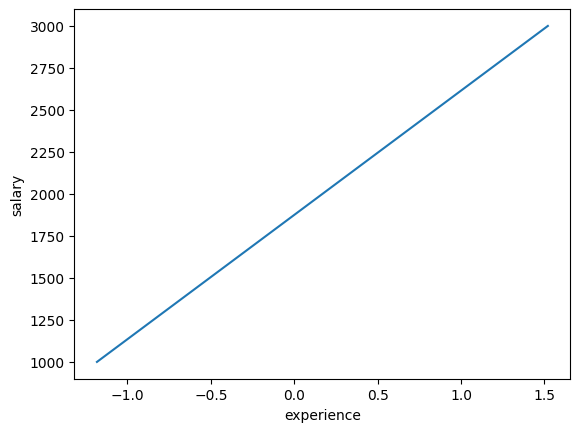

In [ ]:
# data split
X = df['experience'] # captial X
y = df['salary']

print(X)
print(y)

# graph plot
plt.plot(X,y)
plt.xlabel('experience')
plt.ylabel('salary')
plt.show()

In [ ]:
# data split training testing
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = {
      "experience":[300,600,900,1500],
      "salary":[1000,1500,2000,3000]
}

# data frame
df = pd.DataFrame(data)
print(df)



# split data
X = df['experience'] # capital X
y = df['salary']

# train test split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("x train: ",x_train)
print("x test: ",x_test)
print("y train: ", y_train)
print("y test: ", y_test)

   experience  salary
0         300    1000
1         600    1500
2         900    2000
3        1500    3000
x train:  3    1500
0     300
2     900
Name: experience, dtype: int64
x test:  1    600
Name: experience, dtype: int64
y train:  3    3000
0    1000
2    2000
Name: salary, dtype: int64
y test:  1    1500
Name: salary, dtype: int64


In [ ]:
# data split training testing
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data = "https://raw.githubusercontent.com/rajendra0968jangid/Ds-Arya/main/extended_salary_data.csv"

df = pd.read_csv(data)
# print(df)

# split data
X = df[['experience']] # capital X
y = df['salary']

# train test split
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("x train: ",x_train )
print("x test: ",x_test)
print("y train: ", y_train)
print("y test: ", y_test)

x train:       experience
55        17100
22         7200
76        23400
44        13800
72        22200
..          ...
71        21900
14         4800
92        28200
51        15900
102       31200

[83 rows x 1 columns]
x test:      experience
30        9600
65       20100
64       19800
53       16500
45       14100
93       28500
91       27900
47       14700
10        3600
0          300
18        6000
31        9900
88       27000
95       29100
77       23700
4         1800
80       24600
33       10500
12        4200
26        8400
98       30000
y train:  55     29000
22     12500
76     39500
44     23500
72     37500
       ...  
71     37000
14      8500
92     47500
51     27000
102    52500
Name: salary, Length: 83, dtype: int64
y test:  30    16500
65    34000
64    33500
53    28000
45    24000
93    48000
91    47000
47    25000
10     6500
0      1000
18    10500
31    17000
88    45500
95    49000
77    40000
4      3500
80    41500
33    18000
12     7500
26    1

In [ ]:
# simple linear reg | prediction
from sklearn.linear_model import LinearRegression

# model fit
model = LinearRegression()
model.fit(x_train,y_train) # 2d


# model prediction

new_data = {
"experience":[300]
}

df1 = pd.DataFrame(new_data)
print(df1)
pred_data = model.predict(df1)
print(pred_data[0])

   experience
0         300
1000.0000000000143


In [ ]:
# project using mysql and joblib and SLR | MLR
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# pymysql dynamic data
# !pip install pymysql cryptography
import pymysql
conn = pymysql.connect(host="13.220.156.88",user="mluser",database="ml_db",password="mlpass123")
print(conn)
query = "select avg_income,house_age,num_rooms,price,name from houses"
df = pd.read_sql(query,conn)
print(df)

# static data
# data = {
#     "name":['praveen','dheeraj','yash','kunal'],
#     "avg_income":[1000,200,300,400], # hundred and thousand
#     "house_age":[10.2,2.5,3.0,4.0], # 1 to 10
#     "num_rooms":[3,4,5,1], # 1 to 10
#     "price":[10000,7000,15000,11000]
# }

# # data frame
# df = pd.DataFrame(data)

# handle missing values
df.drop("name",axis=1,inplace=True)
# feature scaling
scaler = StandardScaler()
# df[['avg_income','house_age','num_rooms']] = scaler.fit_transform(df[['avg_income','house_age','num_rooms']])
print(df)

# split data
x = df[['avg_income','house_age','num_rooms']]
y = df['price']

# train test split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

# model train
model = LinearRegression()
model.fit(x_train,y_train)

# prediction data
new_data = pd.DataFrame({
    "avg_income":[1200],
    "house_age":[8],
    "num_rooms":[5]
})

# feature scaling
# new_data[['avg_income','house_age','num_rooms']] = scaler.fit_transform(new_data[['avg_income','house_age','num_rooms']])

# prediction
predict_data = model.predict(new_data)
# print(predict_data[0])

# model dump
# !pip install joblib
# import joblib
# joblib.dump(model,"house_model.joblib")

   avg_income  house_age  num_rooms    price     name
0        1000       10.2          3  10000.0  praveen
1         200        2.5          4   7000.0  dheeraj
2         300        3.0          5  15000.0     yash
3         400        4.0          1  11000.0    kunal
   avg_income  house_age  num_rooms    price
0        1000       10.2          3  10000.0
1         200        2.5          4   7000.0
2         300        3.0          5  15000.0
3         400        4.0          1  11000.0


/tmp/ipykernel_4287/4107772409.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,conn)


[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  3.  9.]
 [ 1.  4. 16.]
 [ 1.  5. 25.]]
enter the exper:6
224.0000000000001


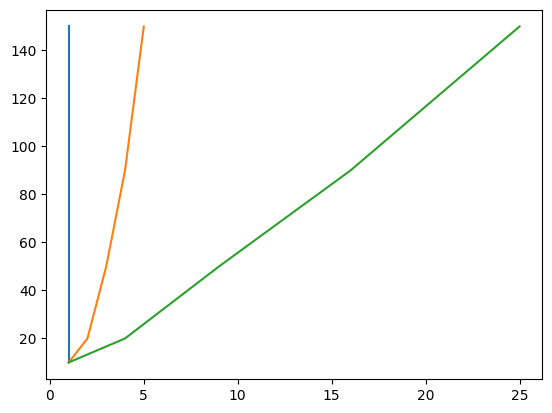

In [16]:
# polynomial regression
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# data
df = pd.DataFrame({
    "Experience":[1,2,3,4,5]
})

x = df
y = [10,20,50,90,150]

# poly feature
poly = PolynomialFeatures(degree=2) # x**2
x_poly = poly.fit_transform(x)
print(x_poly)

# model
model = LinearRegression()
model.fit(x_poly,y)

#prediction
input_data = int(input("enter the exper:"))
new_data = pd.DataFrame({
    "Experience":[input_data]
})
# convert new data to poly
u_new_data = poly.fit_transform(new_data)
predicted_data = model.predict(u_new_data)
print(predicted_data[0])

import matplotlib.pyplot as plt
plt.plot(x_poly,y)
plt.show()

enter the label:6
169.00000000000003


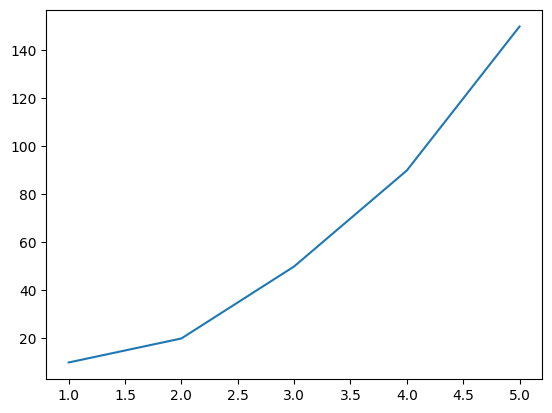

In [19]:
# linear regression -> under fitting
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.DataFrame({
    "label":[1,2,3,4,5]
})
x = df
y = [10,20,50,90,150]

# model
model = LinearRegression()
model.fit(x,y)

# predict
input_data = int(input("enter the label:"))
new_data = pd.DataFrame({
    "label":[input_data]
})

# predicted data
predicted_data = model.predict(new_data)
print(predicted_data[0])

import matplotlib.pyplot as plt
plt.plot(x,y)
plt.show()

enter the label:6
224.0000000000001


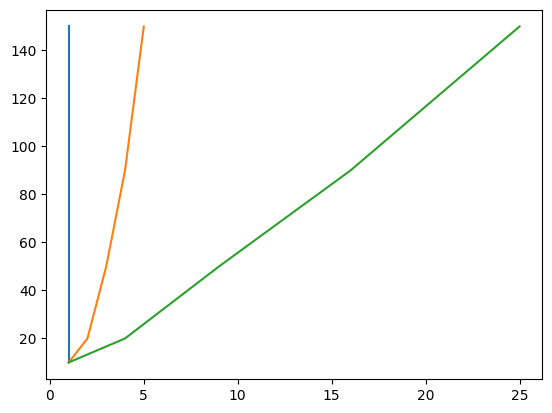

In [20]:
# poly reg
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

df = pd.DataFrame({
    "label":[1,2,3,4,5]
})
x = df
y = [10,20,50,90,150]

# poly convert
poly = PolynomialFeatures(degree=2)
x_poly = poly.fit_transform(x)

# model
model = LinearRegression()
model.fit(x_poly,y)

# predict
input_data = int(input("enter the label:"))
new_data = pd.DataFrame({
    "label":[input_data]
})

# input data to poly
u_new_data = poly.fit_transform(new_data)

# prediction
predicted_data = model.predict(u_new_data)
print(predicted_data[0])

import matplotlib.pyplot as plt
plt.plot(x_poly,y)
plt.show()

enter the weight:110
enter the size:5
Apple


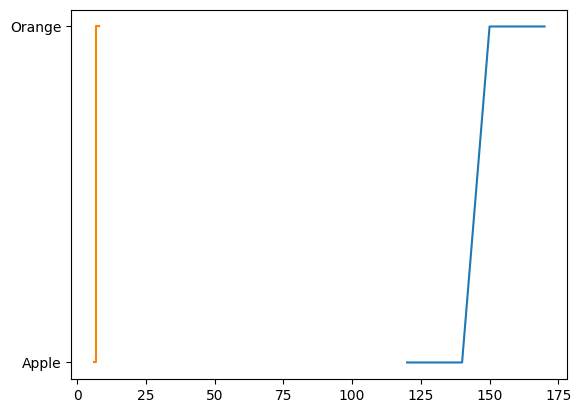

In [23]:
# classification
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

df = pd.DataFrame({
    "Weight":[120,140,150,170],
    "Size":[6,7,7,8]
})

x = df
y = ["Apple","Apple","Orange","Orange"]

# model
model = DecisionTreeClassifier()
model.fit(x,y)

# prediction data
input_weight = int(input("enter the weight:"))
input_size = int(input("enter the size:"))
new_data = pd.DataFrame({
    "Weight":[input_weight],
    "Size":[input_size]
})

# predicted data
predicted_data = model.predict(new_data)
print(predicted_data[0])

import matplotlib.pyplot as plt
plt.plot(x,y)
plt.show()


In [29]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

df = pd.DataFrame({
    "marks":[10,20,25,39,40,55,70,80],
    "result":['fail','fail','fail','fail','pass','pass','pass','pass']
})

x = df[['marks']]
y = df['result']

# model
model = DecisionTreeClassifier()
model.fit(x,y)


# predicted data
input_marks = int(input("enter the marks:"))
new_data = pd.DataFrame({
    "marks":[input_marks]
})

# prediction
model_predict = model.predict(new_data)
print(model_predict[0])

enter the marks:38
fail


In [ ]:
# logistic regression
import pandas as pd
from sklearn.tree import LogisticRegression

df = pd.DataFrame({
    "hours":[1,2,3,4,5,6]
})
